# 02 — Time-Series Exploratory Data Analysis

We look at demand at several levels of aggregation (daily / weekly / monthly, and by product/category) to characterize trend, seasonality, noise, and outliers before engineering any features.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (11, 4)

df = pd.read_csv("../data/sales_clean.csv", parse_dates=["date"])
df.shape

(36346, 10)

## Aggregate daily / weekly / monthly demand

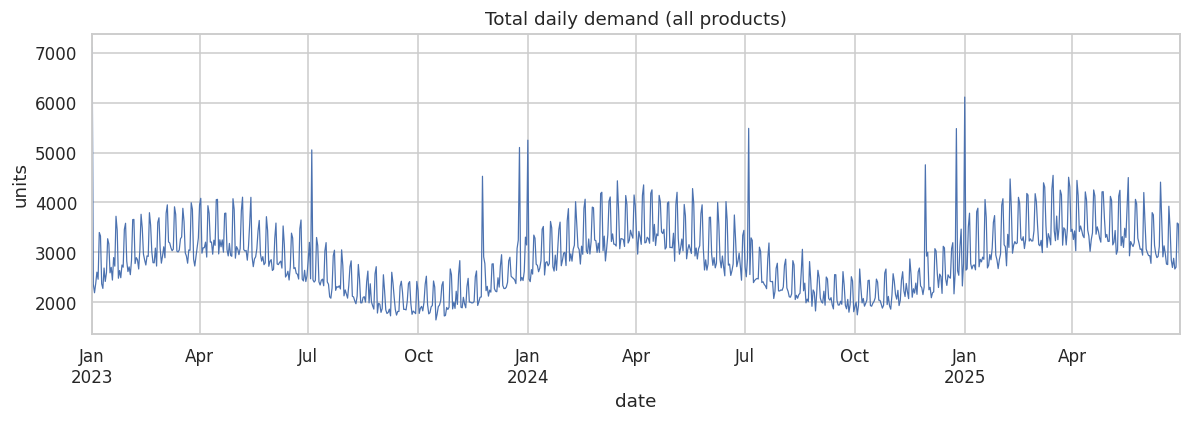

In [2]:
daily = df.groupby("date")["quantity"].sum()

fig, ax = plt.subplots()
daily.plot(ax=ax, lw=0.8)
ax.set_title("Total daily demand (all products)")
ax.set_ylabel("units")
plt.tight_layout()
plt.savefig("../reports/figures/01_daily_demand.png", dpi=110)
plt.show()

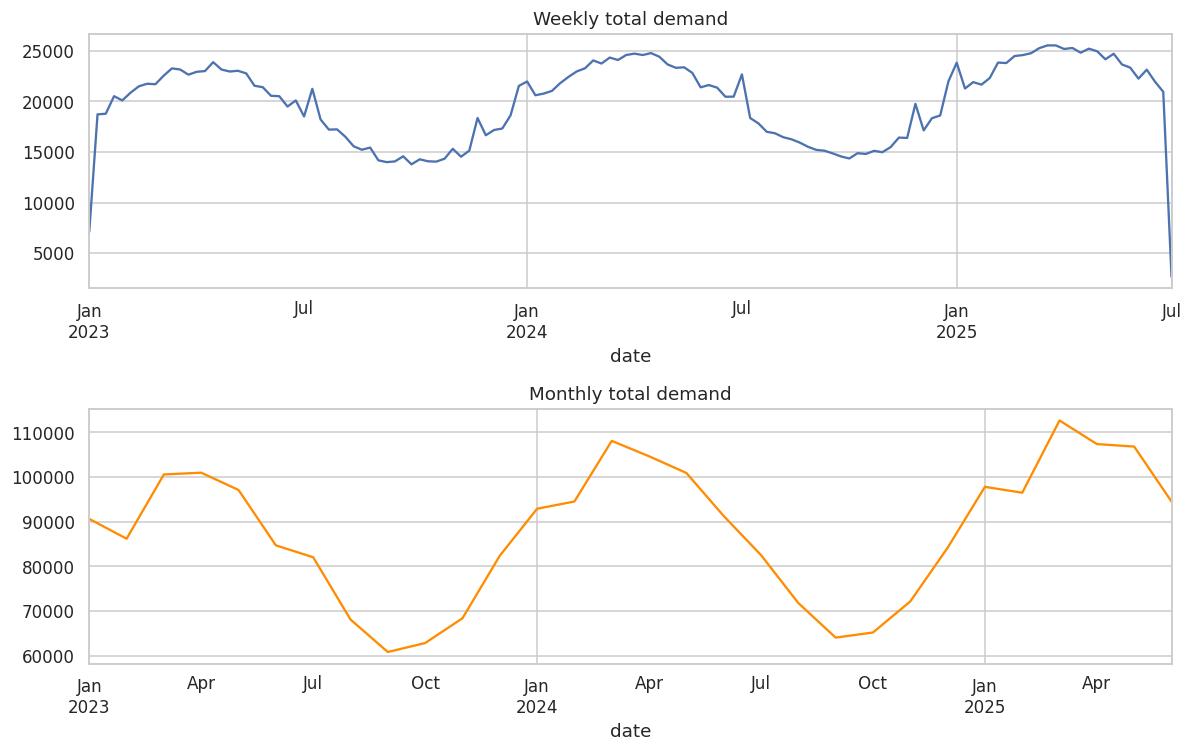

In [3]:
weekly = daily.resample("W").sum()
monthly = daily.resample("MS").sum()

fig, axes = plt.subplots(2, 1, figsize=(11, 7))
weekly.plot(ax=axes[0], title="Weekly total demand")
monthly.plot(ax=axes[1], title="Monthly total demand", color="darkorange")
plt.tight_layout()
plt.savefig("../reports/figures/02_weekly_monthly_demand.png", dpi=110)
plt.show()

**Trend:** monthly totals show a mild upward drift across 2023-2025 with a clear yearly seasonal shape (higher in spring, a summer/early-autumn dip, a winter-holiday bump), consistent with how we generated yearly seasonality and per-product trend slopes.

## Demand by product and by category

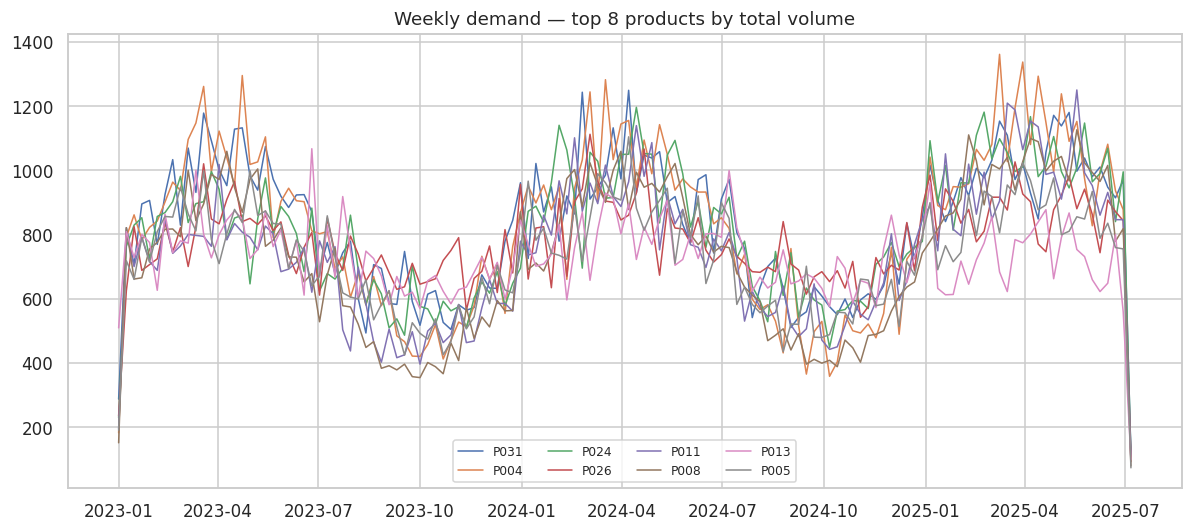

In [4]:
top_products = df.groupby("product_id")["quantity"].sum().sort_values(ascending=False).head(8).index

fig, ax = plt.subplots(figsize=(11, 5))
for p in top_products:
    s = df[df["product_id"] == p].groupby("date")["quantity"].sum().resample("W").sum()
    ax.plot(s.index, s.values, label=p, lw=1)
ax.set_title("Weekly demand — top 8 products by total volume")
ax.legend(ncol=4, fontsize=8)
plt.tight_layout()
plt.savefig("../reports/figures/03_top_products_weekly.png", dpi=110)
plt.show()

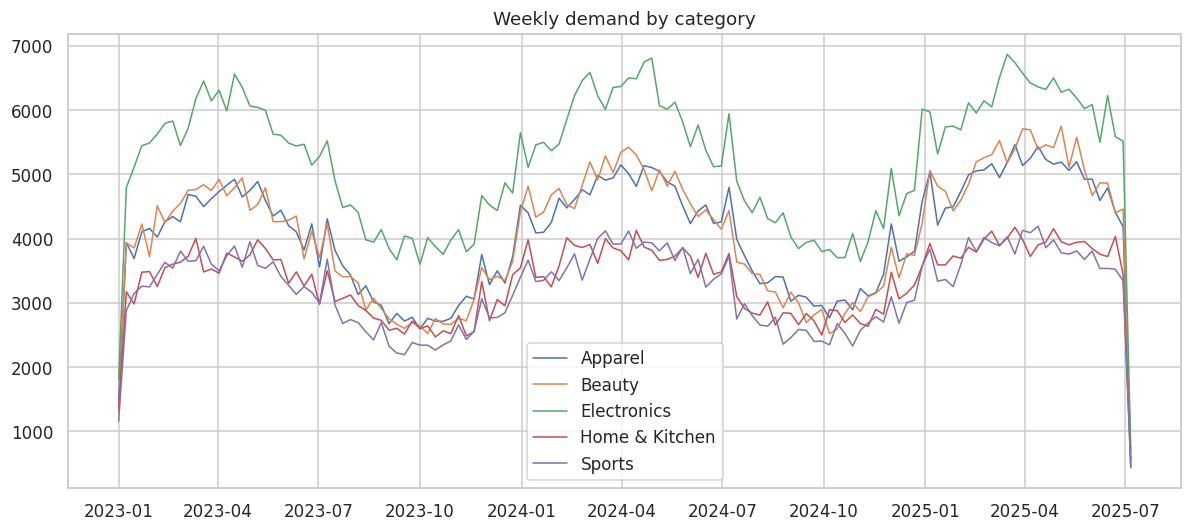

In [5]:
cat_weekly = df.groupby(["category", pd.Grouper(key="date", freq="W")])["quantity"].sum().reset_index()

fig, ax = plt.subplots(figsize=(11, 5))
for cat, g in cat_weekly.groupby("category"):
    ax.plot(g["date"], g["quantity"], label=cat, lw=1)
ax.set_title("Weekly demand by category")
ax.legend()
plt.tight_layout()
plt.savefig("../reports/figures/04_category_weekly.png", dpi=110)
plt.show()

## Seasonality: day-of-week and month-of-year

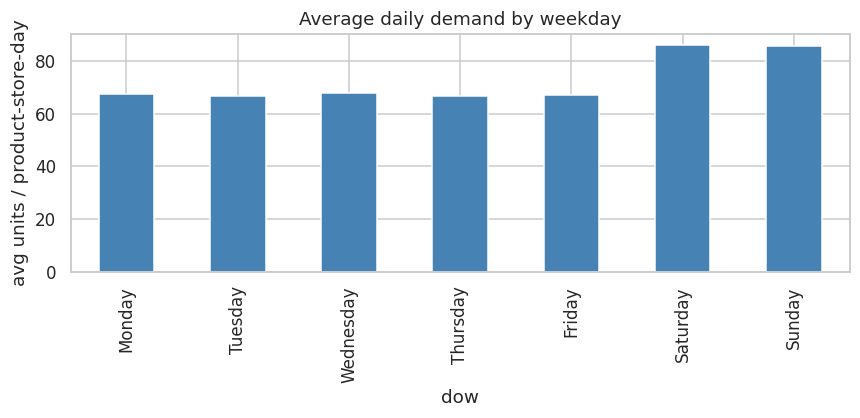

In [6]:
dow = df.copy()
dow["dow"] = dow["date"].dt.day_name()
order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
dow_avg = dow.groupby("dow")["quantity"].mean().reindex(order)

fig, ax = plt.subplots(figsize=(8, 4))
dow_avg.plot(kind="bar", ax=ax, color="steelblue")
ax.set_title("Average daily demand by weekday")
ax.set_ylabel("avg units / product-store-day")
plt.tight_layout()
plt.savefig("../reports/figures/05_weekday_seasonality.png", dpi=110)
plt.show()

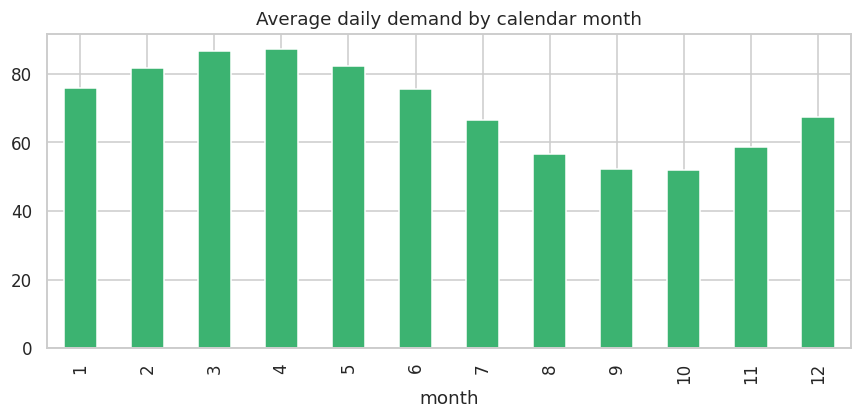

In [7]:
moy = df.copy()
moy["month"] = moy["date"].dt.month
moy_avg = moy.groupby("month")["quantity"].mean()

fig, ax = plt.subplots(figsize=(8, 4))
moy_avg.plot(kind="bar", ax=ax, color="mediumseagreen")
ax.set_title("Average daily demand by calendar month")
ax.set_xlabel("month")
plt.tight_layout()
plt.savefig("../reports/figures/06_monthly_seasonality.png", dpi=110)
plt.show()

**Seasonality confirmed:** weekends (Sat/Sun) run noticeably higher than weekdays, and there is a clear month-of-year pattern — matches the SQL Q7 finding and the generative model's weekly/yearly seasonality terms.

## Noise and outliers

Detected 0 outlier days out of 909 for P031


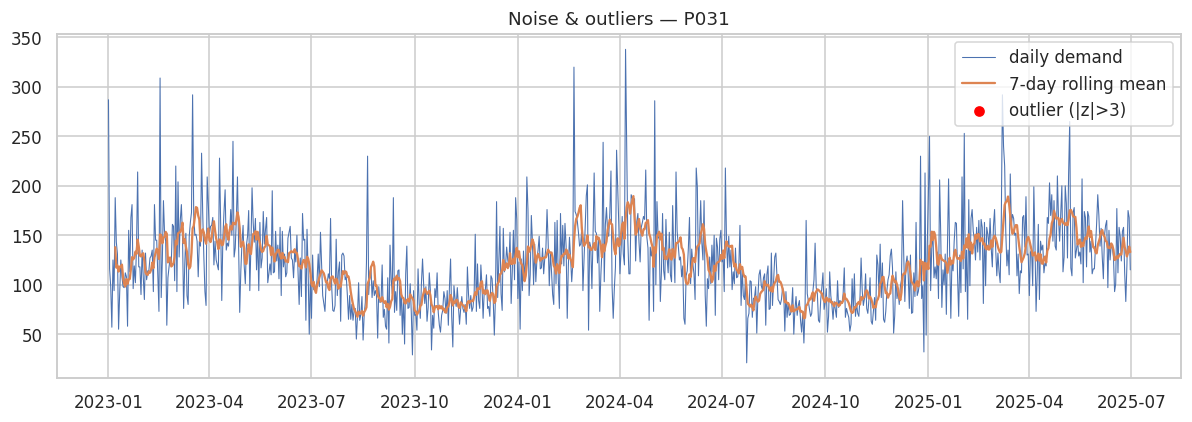

In [8]:
p = "P031"   # a high-volume product
s = df[df["product_id"] == p].groupby("date")["quantity"].sum()
roll_mean = s.rolling(7).mean()
roll_std = s.rolling(7).std()
z = (s - roll_mean) / roll_std
outliers = s[z.abs() > 3]

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(s.index, s.values, lw=0.7, label="daily demand")
ax.plot(roll_mean.index, roll_mean.values, lw=1.5, label="7-day rolling mean")
ax.scatter(outliers.index, outliers.values, color="red", zorder=5, label="outlier (|z|>3)")
ax.set_title(f"Noise & outliers — {p}")
ax.legend()
plt.tight_layout()
plt.savefig("../reports/figures/07_outliers_example.png", dpi=110)
plt.show()
print(f"Detected {len(outliers)} outlier days out of {len(s)} for {p}")

## EDA summary

- **Trend:** slight overall upward drift; trend direction varies by product (confirmed
  quantitatively in SQL Q8 — several products are declining over the most recent 90 days).
- **Seasonality:** strong weekly pattern (weekend lift) and a visible yearly cycle.
- **Noise:** day-to-day demand is noisy around the rolling mean, as expected for retail data.
- **Outliers:** a small number of spike days per product (viral/stock-up events) stand out
  clearly against the 7-day rolling mean — these need to be handled carefully so they don't
  distort lag/rolling features (we keep them, since a forecasting model should be able to
  see that spikes happen, but we flag them for the error-analysis step later).

These properties (autocorrelation + seasonality + trend) are exactly why this needs
time-series-aware features and time-series-aware validation, not a plain i.i.d. regression
setup.